In [9]:
# 1. Підготовка середовища
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Бібліотеки для машинного навчання
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Налаштування стилю графіків
sns.set(style="whitegrid")

# Завантаження даних Titanic з бібліотеки seaborn [cite: 9]
df = sns.load_dataset('titanic')

print("Дані успішно завантажено!")

Дані успішно завантажено!


In [10]:
# 2. Ознайомлення з даними
print("Перші 10 рядків:")
display(df.head(10)) # [cite: 11]

print("\nБазова статистика:")
display(df.describe()) # [cite: 12]

print("\nПеревірка пропущених значень:")
print(df.isnull().sum()) # [cite: 13]

Перші 10 рядків:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False



Базова статистика:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Перевірка пропущених значень:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [11]:
# 3. Попередня обробка даних

# -- Обробка пропущених значень --
# Заповнюємо Age середнім значенням [cite: 16]
df['age'] = df['age'].fillna(df['age'].mean())

# Заповнюємо Embarked модою (найпопулярнішим значенням) [cite: 17, 18]
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# -- Створення нових ознак --
# Додаємо FamilySize (SibSp + Parch) [cite: 23]
df['family_size'] = df['sibsp'] + df['parch']

# -- Видалення зайвих колонок --
# 'deck' має забагато пропусків. 'embark_town', 'who', 'adult_male', 'alive', 'class' 
# дублюють іншу інформацію або не потрібні для моделі.
cols_to_drop = ['deck', 'embark_town', 'who', 'adult_male', 'alive', 'class']
df = df.drop(columns=cols_to_drop, errors='ignore')

# -- Кодування категоріальних змінних --
# One-Hot Encoding для Sex та Embarked [cite: 20, 21]
# drop_first=True видаляє один стовпець, щоб уникнути мультиколінеарності (пастка фіктивних змінних)
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

print("Дані після обробки:")
display(df.head())

Дані після обробки:


,survived,pclass,age,sibsp,parch,fare,alone,family_size,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,1,True,False,True
1,1,1,38.0,1,0,71.2833,False,1,False,False,False
2,1,3,26.0,0,0,7.9250,True,0,False,False,True
3,1,1,35.0,1,0,53.1000,False,1,False,False,True
4,0,3,35.0,0,0,8.0500,True,0,True,False,True


In [12]:
# 4. Поділ даних

X = df.drop('survived', axis=1) # Ознаки
y = df['survived']              # Цільова змінна (вижив чи ні)

# Розподіл на train/test (80% на 20%) [cite: 25]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабування даних (важливо для Логістичної регресії)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір тренувальної вибірки: (712, 10)
Розмір тестової вибірки: (179, 10)


--- Logistic Regression ---
Accuracy: 0.8045, Precision: 0.7826, Recall: 0.7297, F1-score: 0.7552


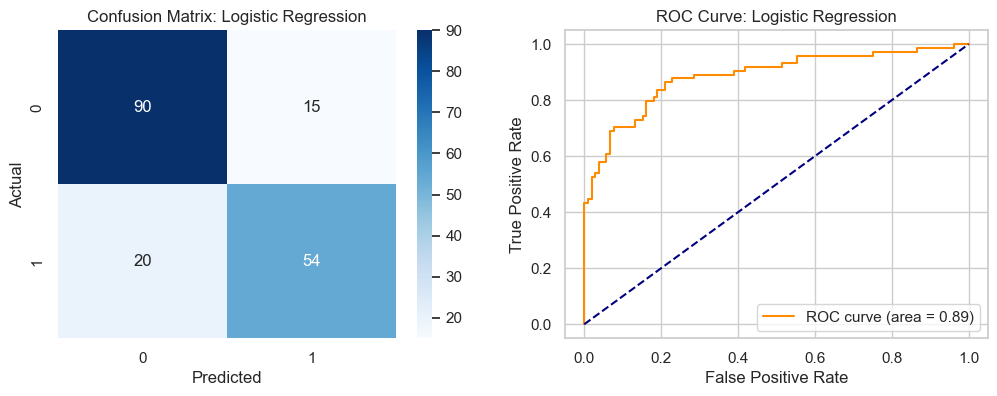

--- Decision Tree ---
Accuracy: 0.7933, Precision: 0.7606, Recall: 0.7297, F1-score: 0.7448


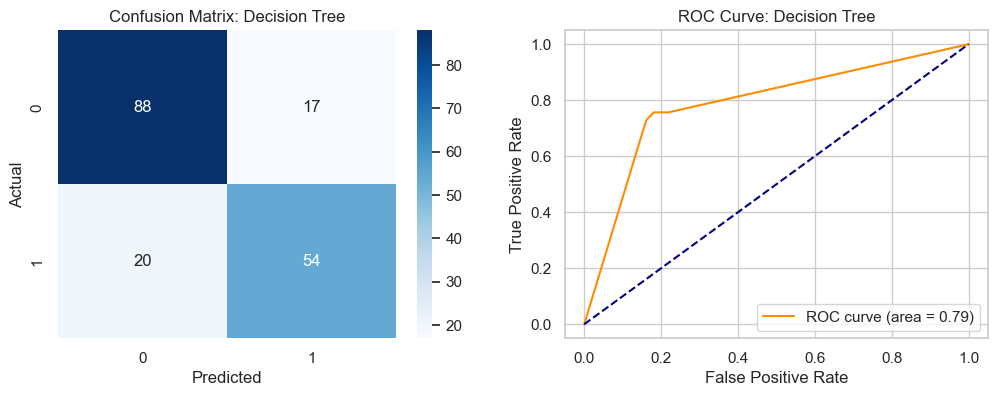

--- Random Forest ---
Accuracy: 0.8212, Precision: 0.8000, Recall: 0.7568, F1-score: 0.7778


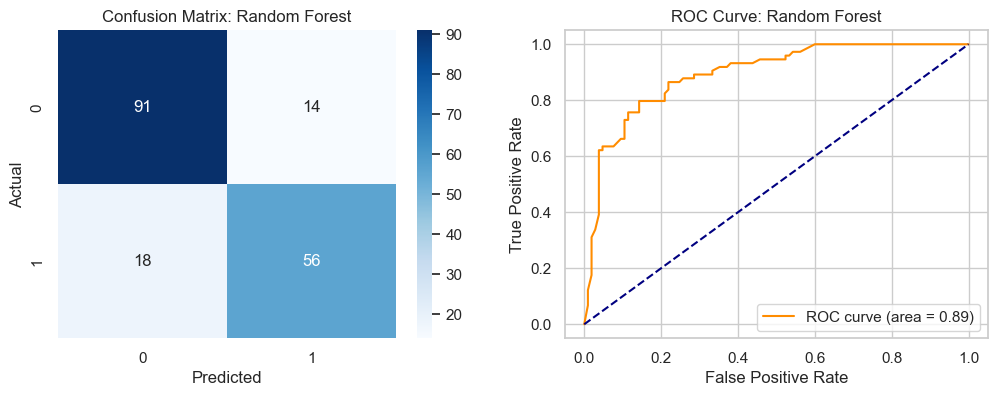

In [13]:
# 5 & 6. Побудова моделей та Оцінка результатів

# Словник для збереження результатів
models_results = {}

def train_evaluate_plot(model, name, X_tr, X_te, y_tr, y_te):
    # Тренування [cite: 36]
    model.fit(X_tr, y_tr)
    
    # Передбачення [cite: 37]
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    # Метрики [cite: 38, 39]
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")
    
    # Зберігаємо для порівняння
    models_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Prob': y_prob}

    # Матриця плутанини [cite: 41]
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # ROC-крива [cite: 42]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    plt.show()

# --- Запуск моделей ---

# 1. Логістична регресія (використовуємо масштабовані дані) [cite: 29]
log_reg = LogisticRegression(random_state=42)
train_evaluate_plot(log_reg, "Logistic Regression", X_train_scaled, X_test_scaled, y_train, y_test)

# 2. Дерево рішень [cite: 31]
dt = DecisionTreeClassifier(random_state=42)
train_evaluate_plot(dt, "Decision Tree", X_train, X_test, y_train, y_test)

# 3. Випадковий ліс [cite: 33]
rf = RandomForestClassifier(random_state=42)
train_evaluate_plot(rf, "Random Forest", X_train, X_test, y_train, y_test)

Крос-валідація (середня точність):
Logistic Regression CV: 0.7991
Decision Tree CV: 0.7430

Найкращі параметри для Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
--- Random Forest (Tuned) ---
Accuracy: 0.8436, Precision: 0.8485, Recall: 0.7568, F1-score: 0.8000


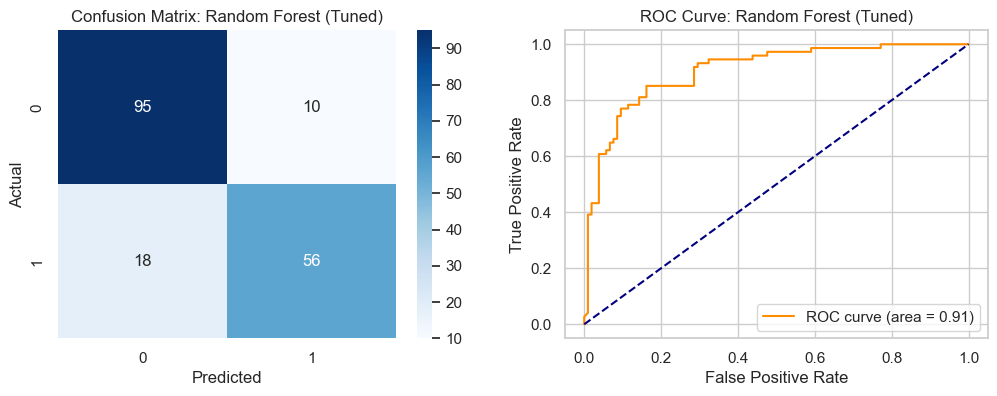

In [14]:
# 7. Оптимізація моделі

print("Крос-валідація (середня точність):")
# Для Логістичної регресії та Дерев [cite: 45]
cv_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_tree = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print(f"Logistic Regression CV: {cv_log.mean():.4f}")
print(f"Decision Tree CV: {cv_tree.mean():.4f}")

# GridSearch для Random Forest [cite: 46, 47]
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"\nНайкращі параметри для Random Forest: {grid_search.best_params_}")

# Оцінка оптимізованої моделі
train_evaluate_plot(best_rf, "Random Forest (Tuned)", X_train, X_test, y_train, y_test)

In [15]:
# 8. Порівняння моделей
results_df = pd.DataFrame(models_results).T
print("Порівняння ефективності моделей:")
display(results_df.sort_values(by='F1', ascending=False))

Порівняння ефективності моделей:


,Accuracy,Precision,Recall,F1,Prob
Random Forest (Tuned),0.843575,0.848485,0.756757,0.8,"[0.2363406015037594, 0.12075292024244699, 0.09..."
Random Forest,0.821229,0.8,0.756757,0.777778,"[0.37, 0.04, 0.05, 0.99, 0.33, 0.97, 0.8340490..."
Logistic Regression,0.804469,0.782609,0.72973,0.755245,"[0.12637063758052128, 0.20050218073519505, 0.1..."
Decision Tree,0.793296,0.760563,0.72973,0.744828,"[0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.8333333333333..."


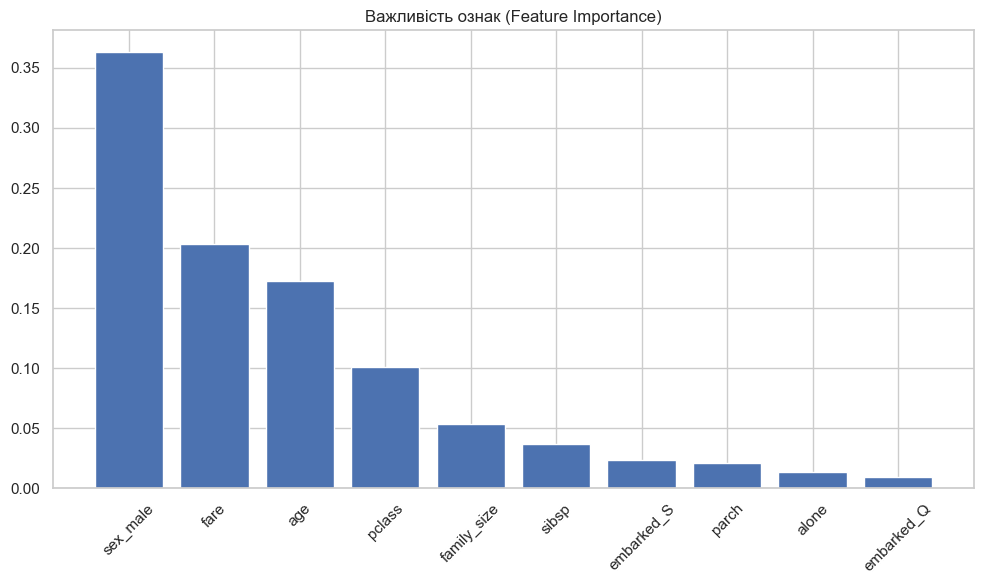

In [16]:
# 9. Аналіз важливості ознак (для Random Forest) [cite: 52]
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10, 6))
plt.title("Важливість ознак (Feature Importance)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=45)
plt.tight_layout()
plt.show()